# Front-Door Criterion

**🌐 Language:** **English** | [한국어 →](/frontdoor-criterion-ko)

<small><em>Written by Haechang Cho · <a href="https://github.com/Funbucket">GitHub</a> · <a href="https://www.linkedin.com/in/hae-chang-cho/">LinkedIn</a></em></small>

We aim to estimate the causal effect of shared rides on tips.

A common belief among drivers is that "allowing shared rides reduces tips." However, whether a passenger opts into a shared ride is not randomly assigned — it may be correlated with unobservable traits such as frugality. Frugal passengers are more likely to choose shared rides and, at the same time, less likely to leave a tip. As a result, a naive comparison or OLS regression may be contaminated by confounding bias.

This question matters because tips are a meaningful component of driver income on Lyft and Uber. A reliable causal estimate lets drivers make informed decisions about participating in shared-ride programs and helps platforms design better incentive policies. It also lets us test whether the "shared rides = fewer tips" narrative reflects a genuine causal effect or is simply an artifact of confounding.

To answer this, we apply the Front-Door Criterion (FDC) to disentangle the pathway: shared-ride authorization (X) → actual shared ride (M) → tip (Y).
- **X:** Whether the passenger authorized a shared ride
- **M:** Whether a shared ride actually occurred
- **Y:** Tip (binary indicator / dollar amount / share of fare)

The key idea is to exploit the exogenous variation in M generated by the app's matching algorithm, thereby separating the effect of the shared ride itself from the characteristics of passengers who opt into sharing.

Our findings show that the negative association between shared rides and tips is driven almost entirely by self-selection into treatment rather than by the shared ride itself. In other words, the tip gap reflects who chooses to share, not what sharing does to tips.

In [199]:
import pandas as pd, numpy as np
import statsmodels.api as sm
import warnings
import duckdb
import matplotlib.pyplot as plt
from linearmodels.system import SUR
from pathlib import Path

warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*", module="dowhy")

## Conceptual Background

1. Shared-ride authorization (X)

    Passengers choose between two service types in the app:

    - **Solo ride** (UberX/Lyft): more convenient but higher fare
    - **Shared ride** (UberPool/LyftLine): discounted fare, but may involve detours for co-passenger pickups and drop-offs

    This choice reflects personal preferences around price vs. convenience. Passengers with stronger frugality tend to opt into shared rides more often.

2. Whether a shared ride actually occurred (M)

    Authorizing a shared ride (X=1) does not guarantee that a match actually happens (M=1). Whether a match occurs depends on the platform's algorithm and real-time demand:

    - If no other passenger in the same area has also authorized a shared ride at that time, the trip is completed as a solo ride (M=0).
    - The probability of an actual shared match (M=1) is higher during peak demand hours or in high-traffic zones.

3. Determinants of tips (Y)

    Key factors that influence tipping:

    - **Passenger frugality (U)**: More frugal passengers tend to tip less — an unobservable confounder.
    - **Fare level**: Tips are conventionally proportional to the total fare, so the lower fare associated with a shared ride reduces the baseline tip amount.
    - **Time and location**: Traffic conditions, trip duration, weather, and similar contextual factors all affect tipping.
    - **Free-rider effect**: Awareness that a co-passenger may tip can reduce any individual's motivation to tip.

## Identification Strategy

Applying the FDC requires establishing conditional exogeneity at each step. We address three sources of endogeneity.

1. Fare endogeneity

    Uber and Lyft display an upfront fare estimate in the app before the trip begins. Passengers who choose a shared ride see a discounted rate relative to a solo ride and then decide whether to authorize sharing (X).

    - **Problem**: Lower fares predict both a higher likelihood of authorizing a shared ride and lower tip amounts.
    - **Response**: Include the final billed amount (full fare) as a control variable in every estimation stage.

2. Time–place endogeneity

    The time of day and location (Z) can affect the shared-ride authorization (X), the actual match (M), and the tip (Y) simultaneously.

    - Z → X: Higher demand increases the probability of authorizing a shared ride.
    - Z → M: Higher demand increases the probability of a successful match.
    - Z → Y: Congestion, trip experience, and similar factors influence tipping.

    **Response**: Include spatiotemporal fixed effects to absorb common confounders.

3. Self-selection bias (Selection into X)

    Passengers with stronger frugality are more likely to authorize shared rides and less likely to tip generously. This unobservable preference biases estimates independently of the fare effect.

    - **Response**: Apply the FDC to separate X→M and M→Y, using only the exogenous variation in M for identification.


**Core of the identification strategy**

We assume that, conditional on fare and spatiotemporal factors, whether a match actually occurs (M=1) after authorization (X=1) is determined exogenously by the platform's matching algorithm. Accordingly, unobservable passenger characteristics such as frugality do not directly affect whether a match takes place.

Under this conditional exogeneity assumption, the FDC identifies the causal effect of shared rides on tips.

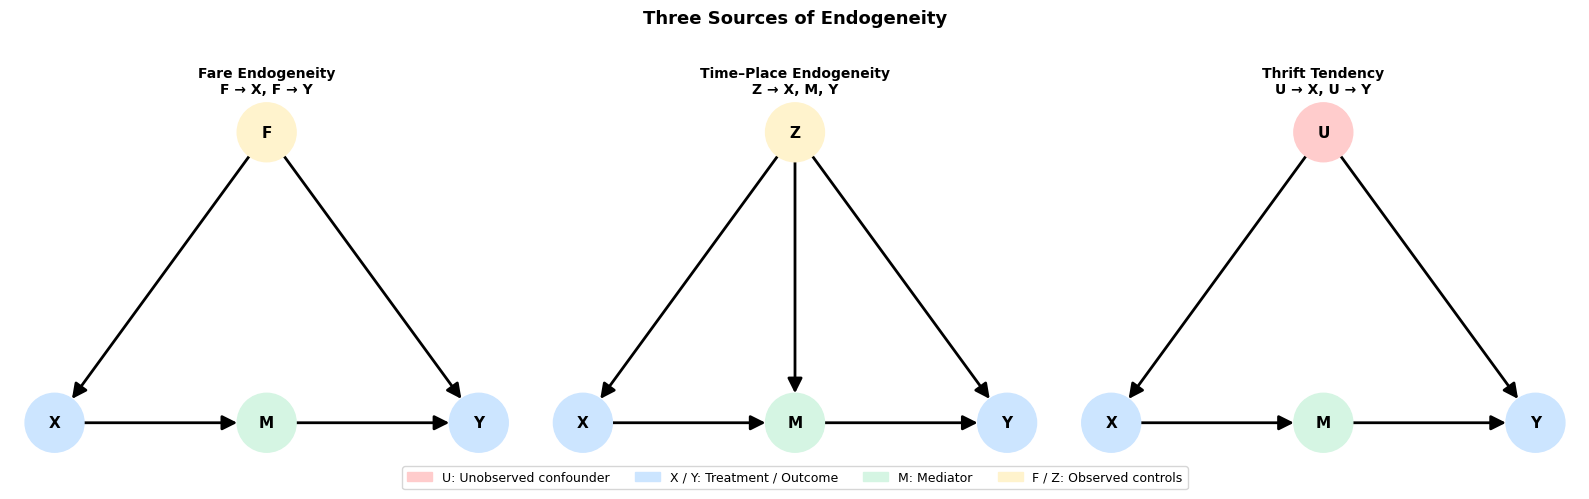

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

NODE_COLORS = {
    'U': '#ffcccc', 'X': '#cce5ff', 'Y': '#cce5ff',
    'M': '#d5f5e3', 'F': '#fff3cd', 'Z': '#fff3cd',
}
DRAW_KW = dict(arrows=True, arrowsize=22, node_size=1800,
               font_size=11, font_weight='bold', width=2.0)

graphs = [
    ('F', [('F','X'),('F','Y'),('X','M'),('M','Y')], 'Fare Endogeneity\nF → X, F → Y'),
    ('Z', [('Z','X'),('Z','M'),('Z','Y'),('X','M'),('M','Y')], 'Time–Place Endogeneity\nZ → X, M, Y'),
    ('U', [('U','X'),('U','Y'),('X','M'),('M','Y')], 'Thrift Tendency\nU → X, U → Y'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (top, edges, title) in zip(axes, graphs):
    G = nx.DiGraph(edges)
    pos = {top: (1, 1.2), 'X': (0, 0), 'M': (1, 0), 'Y': (2, 0)}
    nx.draw_networkx(G, pos=pos, ax=ax,
                     node_color=[NODE_COLORS[n] for n in G.nodes()], **DRAW_KW)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

legend = [
    mpatches.Patch(color='#ffcccc', label='U: Unobserved confounder'),
    mpatches.Patch(color='#cce5ff', label='X / Y: Treatment / Outcome'),
    mpatches.Patch(color='#d5f5e3', label='M: Mediator'),
    mpatches.Patch(color='#fff3cd', label='F / Z: Observed controls'),
]
fig.legend(handles=legend, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Three Sources of Endogeneity', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Data Setup

We apply the methodology of Bellemare & Bloem (2024) to the 2023 New York City HVFHS dataset. We work with a randomly drawn 5M-row sample from the full dataset (230 million rows). On the first run, the sample is downloaded from HuggingFace and cached locally.

In [ ]:
sample_url = "https://huggingface.co/datasets/Funbucket/nyc-hvfhs-2023/resolve/main/nyc_hvfhs_2023_sample5M.parquet"
sample_path = Path.cwd() / "data" / "nyc_hvfhs_2023_sample5M.parquet"
sample_path.parent.mkdir(exist_ok=True)

if not sample_path.exists():
    print("Downloading from HuggingFace...")
    _con = duckdb.connect()
    _con.execute(f"COPY (SELECT * FROM read_parquet('{sample_url}')) TO '{sample_path}' (FORMAT parquet, COMPRESSION zstd)")
    _con.close()
    print(f"Saved: {sample_path.stat().st_size / 1e6:.0f} MB")

con = duckdb.connect()
parquet_path = sample_path

In [156]:
schema_df = con.execute(f"""
DESCRIBE SELECT * FROM read_parquet('{parquet_path.as_posix()}')
""").df()

sample_df = con.execute(f"""
SELECT *
FROM read_parquet('{parquet_path.as_posix()}')
LIMIT 5
""").df()

display(schema_df)
display(sample_df.head())

,column_name,column_type,null,key,default,extra
0,hvfhs_license_num,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,request_datetime,VARCHAR,YES,None,None,None
3,pickup_datetime,TIMESTAMP WITH TIME ZONE,YES,None,None,None
4,dropoff_datetime,VARCHAR,YES,None,None,None
5,pulocationid,VARCHAR,YES,None,None,None
6,dolocationid,VARCHAR,YES,None,None,None
7,trip_miles,VARCHAR,YES,None,None,None
8,trip_time,VARCHAR,YES,None,None,None
9,base_passenger_fare,VARCHAR,YES,None,None,None


,hvfhs_license_num,dispatching_base_num,request_datetime,pickup_datetime,dropoff_datetime,pulocationid,dolocationid,trip_miles,trip_time,base_passenger_fare,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,originating_base_num,on_scene_datetime
0,HV0005,B03406,2023-08-09T06:32:45.000,2023-08-09 15:36:42+09:00,2023-08-09T06:52:44.000,37,177,2.465,962,13.43,...,0.0,0.0,13.9,N,N,N,N,False,NaN,NaN
1,HV0003,B03404,2023-06-05T09:01:57.000,2023-06-05 18:04:54+09:00,2023-06-05T09:16:07.000,231,246,2.42,673,15.36,...,0.0,0.0,13.92,N,N,NaN,N,False,B03404,2023-06-05T09:04:33.000
2,HV0005,B03406,2023-11-27T19:30:59.000,2023-11-28 04:34:34+09:00,2023-11-27T19:44:42.000,69,167,1.454,608,13.29,...,0.0,0.0,7.69,N,N,N,N,False,NaN,NaN
3,HV0005,B03406,2023-08-06T16:13:15.000,2023-08-07 01:14:44+09:00,2023-08-06T16:30:04.000,163,48,1.235,920,14.55,...,0.0,3.9,10.36,N,N,N,N,False,NaN,NaN
4,HV0005,B03406,2023-06-05T04:37:53.000,2023-06-05 13:42:33+09:00,2023-06-05T04:59:09.000,181,256,5.371,996,25.14,...,0.0,0.0,16.39,N,N,N,N,False,NaN,NaN


The key columns used in this analysis are `shared_request_flag` (X), `shared_match_flag` (M), and `tips` (Y).

### Type Normalization

- Cast numeric columns from VARCHAR to the appropriate types,
- Binarize `X_authorized` / `M_shared` from Y/N to 1/0, and
- Parse timestamp columns to TIMESTAMP.

In [157]:
con.execute(f"""
CREATE OR REPLACE VIEW hvfhs_typed AS
WITH t AS (
  SELECT
    *,
    TRY_CAST(base_passenger_fare  AS DECIMAL(18,2)) AS base_passenger_fare_c,
    TRY_CAST(tolls                AS DECIMAL(18,2)) AS tolls_c,
    TRY_CAST(bcf                  AS DECIMAL(18,2)) AS bcf_c,
    TRY_CAST(sales_tax            AS DECIMAL(18,2)) AS sales_tax_c,
    TRY_CAST(congestion_surcharge AS DECIMAL(18,2)) AS congestion_surcharge_c,
    TRY_CAST(airport_fee          AS DECIMAL(18,2)) AS airport_fee_c,
    TRY_CAST(tips                 AS DECIMAL(18,2)) AS tips_c,
    TRY_CAST(driver_pay           AS DECIMAL(18,2)) AS driver_pay_c,
    TRY_CAST(trip_miles           AS DOUBLE)        AS trip_miles_d,
    TRY_CAST(trip_time            AS DOUBLE)        AS trip_time_d,
    TRY_CAST(pulocationid         AS INTEGER)       AS pulocationid_i,
    TRY_CAST(dolocationid         AS INTEGER)       AS dolocationid_i,
    CASE WHEN shared_request_flag = 'Y' THEN 1 ELSE 0 END AS X_authorized,
    CASE WHEN shared_match_flag   = 'Y' THEN 1 ELSE 0 END AS M_shared,
    TRY_STRPTIME(request_datetime,  '%Y-%m-%d %H:%M:%S') AS request_ts,
    TRY_STRPTIME(dropoff_datetime,  '%Y-%m-%d %H:%M:%S') AS dropoff_ts,
    TRY_STRPTIME(on_scene_datetime, '%Y-%m-%d %H:%M:%S') AS on_scene_ts
  FROM read_parquet('{parquet_path.as_posix()}')
)
SELECT * FROM t;
""")

### Derived Variables

- **Full fare** = base + tolls + sales_tax + congestion_surcharge + airport_fee + bcf
  - We use the summed total rather than individual fare components, because passengers see this aggregate amount in the app when choosing a ride type and deciding on a tip.
- **Outcome variables (Y)**:
  - **Tip indicator** (`Y_tip_dummy`): whether any tip was given
  - **Tip amount** (`Y_tip_amount`): the actual dollar amount of the tip
  - **Tip share** (`Y_tip_share`): tip / full fare
- **2-hour time slots**: 0–11 (12 slots per day)
- **Quality filters**: remove negative values, missing values, and outliers
  - `full_fare >= 3.00`: drop abnormally low fares
  - `Y_tip_share BETWEEN 0 AND 5.00`: drop tip-share outliers

In [ ]:
con.execute("""
CREATE OR REPLACE VIEW hvfhs_prep AS

WITH base AS (
  SELECT
    *,
    COALESCE(base_passenger_fare_c,    0)
    + COALESCE(tolls_c,                0)
    + COALESCE(sales_tax_c,            0)
    + COALESCE(congestion_surcharge_c, 0)
    + COALESCE(airport_fee_c,          0)
    + COALESCE(bcf_c,                  0) AS full_fare_c,

    CAST(
      FLOOR(EXTRACT(HOUR FROM (pickup_datetime AT TIME ZONE 'America/New_York')) / 2.0)
      AS INTEGER
    ) AS time_slot_2h
  FROM hvfhs_typed
),
prep AS (
  SELECT
    *,
    CASE WHEN COALESCE(tips_c, 0) > 0 THEN 1 ELSE 0 END AS Y_tip_dummy,
    COALESCE(tips_c, 0)                                 AS Y_tip_amount_c,
    CASE 
      WHEN full_fare_c > 0 THEN COALESCE(tips_c, 0) / full_fare_c 
      ELSE NULL 
    END AS Y_tip_share_c
  FROM base
  WHERE
    COALESCE(trip_time_d,  0.0) >= 0.0
    AND COALESCE(trip_miles_d, 0.0) >= 0.0
    AND pickup_datetime IS NOT NULL
    AND pulocationid IS NOT NULL
    AND dolocationid IS NOT NULL
)
SELECT
  *,
  CAST(full_fare_c      AS DOUBLE) AS full_fare,
  CAST(Y_tip_amount_c   AS DOUBLE) AS Y_tip_amount,
  CAST(Y_tip_share_c    AS DOUBLE) AS Y_tip_share
FROM prep
WHERE
  full_fare_c >= 3.00
  AND (Y_tip_share_c IS NULL OR Y_tip_share_c BETWEEN 0 AND 5.00);

""")

con.execute("SELECT COUNT(*) AS n FROM hvfhs_prep").df().head()


,n
0,4998358


### One-Sided Noncompliance Check

In practice, a passenger who did not authorize a shared ride (X=0) cannot be matched (M=1), so the FDC estimates the ATT rather than the ATE. Here we verify the violation rate — the share of trips where M=1 but X=0.

In [196]:
con.execute("""
SELECT
  SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END) AS violations,
  SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END)                     AS all_shared,
  1.0 * SUM(CASE WHEN M_shared=1 AND X_authorized=0 THEN 1 ELSE 0 END)
      / NULLIF(SUM(CASE WHEN M_shared=1 THEN 1 ELSE 0 END),0)     AS violation_rate
FROM hvfhs_prep
""").fetchdf()


,violations,all_shared,violation_rate
0,295.0,44428.0,0.00664


Of the 44,428 actual shared rides, only 295 (0.66%) are violations (M=1 with X=0). The one-sided noncompliance assumption holds in practice; we confirm robustness in a sensitivity check that excludes the violating cells.

### Spatiotemporal Fixed Effects: Demeaning

Instead of including thousands of dummy variables, we absorb fixed effects by subtracting within-cell means.

- **Cell definition**: `pulocationid` (pickup taxi zone) × `dolocationid` (dropoff taxi zone) × `time_slot_2h` (2-hour slot)
- **Absorbing fixed effects**: Subtracting each cell's mean removes any time-invariant unobservable factors within that cell. This is numerically equivalent to a regression with millions of cell dummies. ([Facure 2022, Ch.14](https://matheusfacure.github.io/python-causality-handbook/14-Panel-Data-and-Fixed-Effects.html))
- **Mixed platforms**: Uber and Lyft trips are not separately identified in the data, but since we compare trips within the same spatiotemporal cell, algorithmic differences between platforms are largely absorbed.

In [160]:
CACHE_DF = Path.cwd() / "data" / "df_demeaned.parquet"

if CACHE_DF.exists():
    df = con.execute(f"SELECT * FROM read_parquet('{CACHE_DF.as_posix()}')").fetchdf()
    print(f"Cache loaded  {df.shape}")
else:
    con.execute("""
        CREATE OR REPLACE TEMP VIEW cell_means AS
        SELECT
          pulocationid_i AS pu,
          dolocationid_i AS do,
          time_slot_2h   AS ts,
          AVG(X_authorized) AS X_bar,
          AVG(M_shared)     AS M_bar,
          AVG(full_fare)    AS F_bar,
          AVG(Y_tip_dummy)  AS Yd_bar,
          AVG(Y_tip_amount) AS Ya_bar,
          AVG(Y_tip_share)  AS Ys_bar
        FROM hvfhs_prep
        GROUP BY 1, 2, 3
    """)

    con.execute("""
        CREATE OR REPLACE TEMP VIEW demeaned AS
        SELECT
          s.pulocationid_i AS pu,
          s.dolocationid_i AS do,
          s.time_slot_2h   AS ts,
          s.X_authorized - m.X_bar  AS X_tilde,
          s.M_shared     - m.M_bar  AS M_tilde,
          s.full_fare    - m.F_bar  AS F_tilde,
          s.Y_tip_dummy  - m.Yd_bar AS Yd_tilde,
          s.Y_tip_amount - m.Ya_bar AS Ya_tilde,
          s.Y_tip_share  - m.Ys_bar AS Ys_tilde
        FROM hvfhs_prep s
        JOIN cell_means m
          ON s.pulocationid_i = m.pu
         AND s.dolocationid_i = m.do
         AND s.time_slot_2h   = m.ts
        WHERE s.Y_tip_share IS NOT NULL
    """)

    con.execute(f"COPY demeaned TO '{CACHE_DF.as_posix()}' (FORMAT parquet)")
    df = con.execute("SELECT * FROM demeaned").fetchdf()
    print(f"✓ Demeaning done & cached: {CACHE_DF}")

df.info(show_counts=True)

Cache loaded  (4998358, 9)
<class 'pandas.DataFrame'>
RangeIndex: 4998358 entries, 0 to 4998357
Data columns (total 9 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   pu        4998358 non-null  int32  
 1   do        4998358 non-null  int32  
 2   ts        4998358 non-null  int32  
 3   X_tilde   4998358 non-null  float64
 4   M_tilde   4998358 non-null  float64
 5   F_tilde   4998358 non-null  float64
 6   Yd_tilde  4998358 non-null  float64
 7   Ya_tilde  4998358 non-null  float64
 8   Ys_tilde  4998358 non-null  float64
dtypes: float64(6), int32(3)
memory usage: 286.0 MB


## Estimation

Applying the FDC requires three assumptions.

1. **Exclusion restriction**: Conditional on Full Fare (F) and spatiotemporal fixed effects (FE), the only pathway through which X affects Y runs through M.

2. **X–M exogeneity**: Conditional on Full Fare (F) and spatiotemporal fixed effects (FE), X is exogenous with respect to M.
$$M(x) \perp X \mid \text{F},\ \text{FE}$$

3. **M–Y exogeneity**: Conditional on X, F, and FE, M is effectively exogenous.
$$Y(m) \perp M \mid X,\ \text{F},\ \text{FE}$$

### Estimating the Causal Effect

$\text{ATT} = \gamma \times \delta$. By Assumption 1, any effect of X on Y must pass through M:

$$X \xrightarrow{\gamma} M \xrightarrow{\delta} Y$$

A unit increase in X raises M by $\gamma$, which in turn shifts Y by $\gamma \times \delta$. The total causal effect is the product of the two coefficients.

The standard error of $\gamma \times \delta$ is obtained via the delta method:

$$\text{Var}(\gamma\delta) = \delta^2\text{Var}(\gamma) + \gamma^2\text{Var}(\delta) + 2\gamma\delta\,\text{Cov}(\gamma, \delta)$$

The first two terms can be recovered from separate OLS regressions, but the last term, $\text{Cov}(\gamma, \delta)$, cannot. Because $\hat{\gamma}$ and $\hat{\delta}$ are estimated from the same data they are not independent, yet separate OLS regressions treat them as if they were.

We therefore use Seemingly Unrelated Regressions (SUR), which jointly estimates both stages and directly yields $\text{Cov}(\gamma, \delta)$.

In [198]:
def ci(b, se): return f"[{b - 1.96*se:.4f}, {b + 1.96*se:.4f}]"

def run_fdc(df, outcome_col):
    d = df[['X_tilde', 'F_tilde', 'M_tilde', outcome_col]].dropna()
    res = SUR({
        'stage1': {'dependent': d[['M_tilde']], 'exog': d[['X_tilde', 'F_tilde']]},
        'stage2': {'dependent': d[[outcome_col]], 'exog': d[['M_tilde', 'X_tilde', 'F_tilde']]}
    }).fit(cov_type='robust')

    gamma     = res.params['stage1_X_tilde']
    delta     = res.params['stage2_M_tilde']
    var_gamma = res.cov.loc['stage1_X_tilde', 'stage1_X_tilde']
    var_delta = res.cov.loc['stage2_M_tilde', 'stage2_M_tilde']
    cov_gd    = res.cov.loc['stage1_X_tilde', 'stage2_M_tilde']

    ate    = gamma * delta
    se_ate = (delta**2 * var_gamma + gamma**2 * var_delta + 2*gamma*delta*cov_gd) ** 0.5
    return res, gamma, delta, ate, se_ate

res_d, gamma, delta_d, ate_dummy,  se_ate_dummy  = run_fdc(df, 'Yd_tilde')
res_a, _,     delta_a, ate_amount, se_ate_amount = run_fdc(df, 'Ya_tilde')
res_s, _,     delta_s, ate_share,  se_ate_share  = run_fdc(df, 'Ys_tilde')

### First Stage

$$
M = \kappa + \gamma X + \tau F + FE + \omega
$$

Full Fare (F) and spatiotemporal fixed effects (FE) close the X–M backdoor path. After absorbing FE via demeaning, the estimating equation becomes $\tilde{M} \sim \tilde{X} + \tilde{F}$.

In [188]:
display(res_d.summary.tables[1])

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
X_tilde,0.3169,0.0012,257.94,0.0000,0.3145,0.3194
F_tilde,-0.0001,2.93e-06,-47.648,0.0000,-0.0001,-0.0001


Even when a passenger authorizes a shared ride, an actual match occurs in only about 32% of trips. The remainder are completed as solo rides due to insufficient demand or the platform's internal matching algorithm.

### Second Stage

$$
Y = \lambda + \delta M + \phi X + \pi F + FE + \nu
$$

Full Fare (F) and spatiotemporal fixed effects (FE) close the M–Y backdoor path. After absorbing FE via demeaning, the estimating equation becomes $\tilde{Y} \sim \tilde{M} + \tilde{X} + \tilde{F}$.

In [189]:
for label, res in [('Tip Dummy', res_d), ('Tip Amount', res_a), ('Tip Share', res_s)]:
    print(f"\n{label}")
    display(res.summary.tables[2])


Tip Dummy


,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
M_tilde,0.0049,0.0019,2.6411,0.0083,0.0013,0.0086
X_tilde,-0.0706,0.0010,-69.046,0.0000,-0.0726,-0.0686
F_tilde,0.0008,2.187e-05,37.424,0.0000,0.0008,0.0009



Tip Amount


,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
M_tilde,0.0567,0.0104,5.4581,0.0000,0.0363,0.0770
X_tilde,-0.2258,0.0060,-37.430,0.0000,-0.2376,-0.2139
F_tilde,0.0475,0.0010,47.404,0.0000,0.0456,0.0495



Tip Share


,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
M_tilde,0.0033,0.0004,8.4998,0.0000,0.0026,0.0041
X_tilde,-0.0150,0.0002,-70.173,0.0000,-0.0154,-0.0145
F_tilde,4.934e-05,2.796e-06,17.642,0.0000,4.385e-05,5.482e-05


The actual occurrence of a shared ride (M) shows a positive effect on all three outcome variables.

Meanwhile, the coefficient on shared-ride authorization (X) is significantly negative. We interpret this as self-selection bias: passengers with stronger frugality are more likely to authorize shared rides and also less likely to tip generously.

In [190]:
display(pd.DataFrame({
    'Outcome':    ['Tip Dummy', 'Tip Amount', 'Tip Share'],
    'γ (X→M)':   [gamma, gamma, gamma],
    'δ (M→Y)':   [delta_d, delta_a, delta_s],
    'ATT = γ×δ': [ate_dummy, ate_amount, ate_share],
    '95% CI':     [ci(ate_dummy,  se_ate_dummy),
                   ci(ate_amount, se_ate_amount),
                   ci(ate_share,  se_ate_share)],
}).set_index('Outcome'))

,γ (X→M),δ (M→Y),ATT = γ×δ,95% CI
Outcome,,,,
Tip Dummy,0.316947,0.004942,0.001566,"[0.0004, 0.0027]"
Tip Amount,0.316947,0.056690,0.017968,"[0.0115, 0.0244]"
Tip Share,0.316947,0.003345,0.001060,"[0.0008, 0.0013]"


Across all three outcome variables, the pure causal effect of a shared ride on tipping is significantly positive. The conventional wisdom that "shared rides reduce tips" turns out to be an illusion driven by confounding — the true causal effect runs in the opposite direction.

### Sensitivity Check

Although the violation rate was only 0.66%, we re-estimate the ATT after dropping the violating cells to confirm robustness.

In [191]:
viol_cells = con.execute("""
    SELECT DISTINCT pulocationid_i AS pu, dolocationid_i AS do, time_slot_2h AS ts
    FROM hvfhs_prep WHERE M_shared = 1 AND X_authorized = 0
""").fetchdf()

df_strict = (df.merge(viol_cells.assign(_v=True), on=['pu','do','ts'], how='left')
               .query('_v != _v').drop(columns='_v'))

gamma_s = sm.OLS(df_strict['M_tilde'],
                 sm.add_constant(df_strict[['X_tilde','F_tilde']])).fit(cov_type='HC1').params['X_tilde']

d2s = df_strict[['M_tilde','X_tilde','F_tilde','Yd_tilde']].dropna()
delta_s = sm.OLS(d2s['Yd_tilde'],
                 sm.add_constant(d2s[['M_tilde','X_tilde','F_tilde']])).fit(cov_type='HC1').params['M_tilde']

ate_strict = gamma_s * delta_s
print(f"ATT (full):   {ate_dummy:.6f}")
print(f"ATT (strict): {ate_strict:.6f}")
print(f"Difference:   {abs(ate_dummy - ate_strict):.6f}")

ATT (full):   0.001566
ATT (strict): 0.001574
Difference:   0.000007


Dropping the violating cells changes the ATT by only 0.000007 — a negligible difference.

### Comparison with Naive OLS (Quantifying Confounding Bias)

- Naive: $\tilde Y \sim \tilde X + \tilde F$ (without M) → contains confounding bias
- Both methods estimate the ATT, but Naive OLS conflates the causal effect of shared rides with confounding bias from frugality (U), whereas FDC removes that bias.
- In contrast to the negative Naive estimate, the FDC estimate is small but significantly positive.

    → Most of the observed negative relationship between shared-ride authorization and tips stems from confounding bias. The causal effect of sharing itself is negligible.

In [192]:
def naive(outcome_col):
    dn = df[['X_tilde','F_tilde', outcome_col]].dropna()
    fit = sm.OLS(dn[outcome_col], sm.add_constant(dn[['X_tilde','F_tilde']])).fit(cov_type='HC1')
    b, se = fit.params['X_tilde'], fit.bse['X_tilde']
    return b, se

nb_d, nse_d = naive('Yd_tilde')
nb_a, nse_a = naive('Ya_tilde')
nb_s, nse_s = naive('Ys_tilde')

def ci(b, se): return f"[{b - 1.96*se:.4f}, {b + 1.96*se:.4f}]"

pd.DataFrame({
    'Outcome':       ['Tip Dummy', 'Tip Amount', 'Tip Share'],
    'Naive (X→Y)':   [nb_d,  nb_a,  nb_s],
    'Naive 95% CI':  [ci(nb_d, nse_d), ci(nb_a, nse_a), ci(nb_s, nse_s)],
    'FDC ATT (γ×δ)': [ate_dummy, ate_amount, ate_share],
    'FDC 95% CI':    [ci(ate_dummy,  se_ate_dummy),
                      ci(ate_amount, se_ate_amount),
                      ci(ate_share,  se_ate_share)],
}).set_index('Outcome')

,Naive (X→Y),Naive 95% CI,FDC ATT (γ×δ),FDC 95% CI
Outcome,,,,
Tip Dummy,-0.069044,"[-0.0708, -0.0673]",0.001566,"[0.0004, 0.0027]"
Tip Amount,-0.207791,"[-0.2214, -0.1942]",0.017968,"[0.0115, 0.0244]"
Tip Share,-0.013906,"[-0.0143, -0.0135]",0.001060,"[0.0008, 0.0013]"


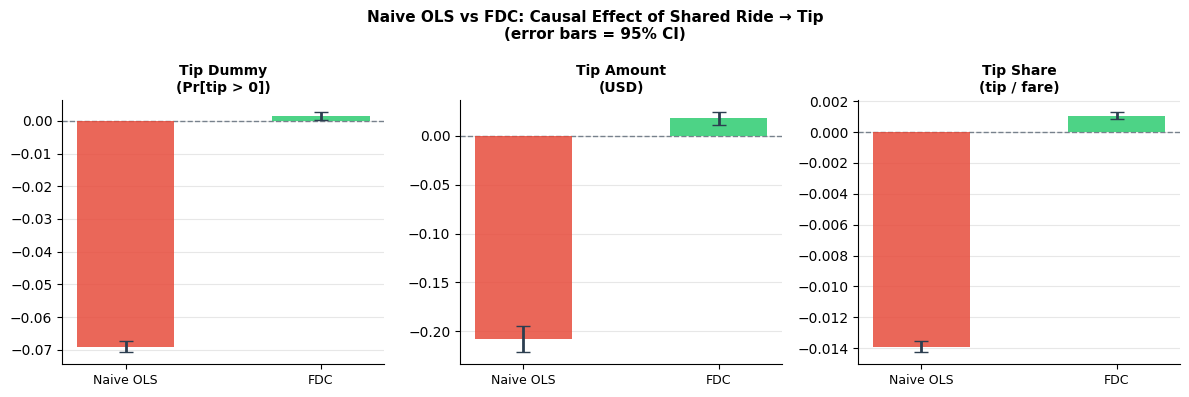

In [ ]:
outcomes = ['Tip Dummy\n(Pr[tip > 0])', 'Tip Amount\n(USD)', 'Tip Share\n(tip / fare)']
naive_vals = [nb_d, nb_a, nb_s]
naive_cis  = [1.96*nse_d, 1.96*nse_a, 1.96*nse_s]
fdc_vals   = [ate_dummy, ate_amount, ate_share]
fdc_cis    = [1.96*se_ate_dummy, 1.96*se_ate_amount, 1.96*se_ate_share]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, outcome, n_v, n_ci, f_v, f_ci in zip(axes, outcomes, naive_vals, naive_cis, fdc_vals, fdc_cis):
    for i, (val, err, color) in enumerate(zip([n_v, f_v], [n_ci, f_ci], ['#e74c3c', '#2ecc71'])):
        ax.bar(i, val, color=color, alpha=0.85, width=0.5, zorder=3)
        ax.errorbar(i, val, yerr=err, fmt='none', color='#2c3e50', capsize=5, linewidth=2, zorder=4)
    ax.axhline(0, color='#2c3e50', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Naive OLS', 'FDC'], fontsize=9)
    ax.set_title(outcome, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Naive OLS vs FDC: Causal Effect of Shared Ride → Tip\n(error bars = 95% CI)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Naive OLS (red) yields large negative estimates for all three outcomes, while FDC (green) produces small positive estimates near zero. The gap between the two bars is the magnitude of confounding bias attributable to passenger frugality (U). The FDC error bars lie entirely above the zero line, confirming a statistically significant positive causal effect.

## Conclusion

| Method | Change in Tip Probability | Change in Tip Amount | Change in Tip Share |
|:-------|:------------------------:|:--------------------:|:-------------------:|
| Naive OLS (ATT, with confounding bias) | −6.9 pp | −$0.21 | −1.4 pp |
| FDC (ATT, confounding bias removed) | +0.16 pp | +$0.018 | +0.11 pp |

Both methods estimate the ATT due to one-sided noncompliance.

- The negative coefficient from **Naive OLS** reflects confounding bias driven by passenger frugality (U), not the actual effect of shared rides. The Naive estimate is **roughly 12–44× larger** than the FDC estimate and arises from self-selection into treatment.
- The **FDC estimate**, free of confounding bias, shows that the true causal effect of a shared ride on tipping is small but statistically significant and positive.

### Business Implications

*Who* opts into shared rides (i.e., frugal passengers) has a far larger influence on tipping than the shared ride itself. Tip incentive programs designed around customer segmentation are likely to be more effective than policies targeting shared-ride participation per se.

### When the FDC Is Useful

The FDC is effective when all of the following conditions hold:
- The treatment (X) is endogenously determined by an unobservable variable (U),
- A conditionally exogenous mediator M exists between X and Y (e.g., an algorithmically determined match), and
- Variation in M arises effectively exogenously.

### Methodological Limitations

- **FDC Assumption 1** (all X→Y effects pass through M): This cannot be directly tested. We cannot rule out the possibility that merely knowing a ride is shared influences tipping psychology directly.
- **Standard errors**: SUR directly estimates Cov(γ, δ), but because we use heteroskedasticity-robust (HC) standard errors rather than clustered standard errors, they may be understated.

## References

This notebook draws primarily on Matheus Facure's *Causal Inference for the Brave and True* and Bellemare & Bloem (2024).

- **Bellemare, M. F., & Bloem, J. R. (2024)**. The Paper of How: Estimating Treatment Effects Using the Front-Door Criterion. *Oxford Bulletin of Economics and Statistics*.  
  [https://marcfbellemare.com/wordpress/wp-content/uploads/2024/01/BellemareBloemWexlerFDCJanuary2024ForthcomingOBES.pdf](https://marcfbellemare.com/wordpress/wp-content/uploads/2024/01/BellemareBloemWexlerFDCJanuary2024ForthcomingOBES.pdf)

- **Facure, M. (2022)**. *Causal Inference for the Brave and True*. Online book.  
  [https://matheusfacure.github.io/python-causality-handbook/](https://matheusfacure.github.io/python-causality-handbook/)

- **NYC TLC — 2023 High Volume For-Hire Vehicle Trip Records**.  
  [https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)